<a href="https://colab.research.google.com/github/JuanZapa7a/AINavalEngineering/blob/main/Prac_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 11: A Machine Learning Project in Python Step-By-Step

We need to see how all of the pieces of a predictive modeling machine learning project actually
fit together. In this lesson you will complete your first machine learning project using Python.
In this step-by-step tutorial project you will:
- Download and install Python SciPy and get the most useful package for machine learning
in Python.
- Load a dataset and understand it’s structure using statistical summaries and data visual-
ization.
- Create 6 machine learning models, pick the best and build confidence that the accuracy is
reliable.

## The Hello World of Machine Learning

The best small project to start with on a new tool is the classification of naval dataset. This is a
good dataset for your first project because it is so well understood.
- Attributes are numeric so you have to figure out how to load and handle data.
- It is a classification problem, allowing you to practice with an easier type of supervised
learning algorithm.
- It is a multiclass classification problem (multi-nominal) that may require some specialized
handling.
- It only has 4 attributes and 150 rows, meaning it is small and easily fits into memory (and
a screen or single sheet of paper).
- All of the numeric attributes are in the same units and the same scale not requiring any
special scaling or transforms to get started.

We are going to work through a small machine learning project end-to-end.
Here is an overview of what we are going to cover:
1. Loading the dataset.
2. Summarizing the dataset.
3. Visualizing the dataset.
4. Evaluating some algorithms.
5. Making some predictions.

Take your time and work through each step. Try to type in the commands yourself or
copy-and-paste the commands to speed things up. Start your Python interactive environment
and let’s get started with your hello world machine learning project in Python.

## Load The Data
In this step we are going to load the libraries and the naval data CSV file from URL.

---
**Load libraries**

---

In [32]:
# Load libraries
from pandas import read_csv
from pandas.plotting import scatter_matrix
from matplotlib import pyplot
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

Everything should load without error. If you have an error, stop. You need a working SciPy
environment before continuing.

---
**Load Dataset**

---

The the naval data CSV dataset file from URL can be downloaded. We are using
Pandas to load the data. We will also use Pandas next to explore the data both with descriptive statistics and data visualization. Note that we are specifying the names of each column when
loading the data. This will help later when we explore the data.

In [33]:
!wget -O /content/sample_data/Naval_Dataset3.csv https://raw.githubusercontent.com/JuanZapa7a/AINavalEngineering/main/Datasets/Naval_Dataset3.csv

--2025-04-03 08:07:40--  https://raw.githubusercontent.com/JuanZapa7a/AINavalEngineering/main/Datasets/Naval_Dataset3.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5714 (5.6K) [text/plain]
Saving to: ‘/content/sample_data/Naval_Dataset3.csv’

/content/sample_dat 100%[===================>]   5.58K  --.-KB/s    in 0s      

2025-04-03 08:07:40 (54.1 MB/s) - ‘/content/sample_data/Naval_Dataset3.csv’ saved [5714/5714]



In [34]:
# Load the dataset
filename = '/content/sample_data/Naval_Dataset3.csv'
names = ['Length (m)','Beam (m)','Draft (m)','Displacement (Tn)','Vessel Type']
data = read_csv(filename, names=names)
array = data.values

#### **Features (numerical columns)**
These are key dimensions of naval structures, such as:
1. **Length** (length of vessel)
2. **Beam** (width of vessel)
3. **Draft** (submerged depth)
4. **Block coefficient** (ratio of hull volume to enveloping parallelepiped)

#### **Classes (types of vessels or naval structures)**
Classes represent different types of vessels **Vessel Type** with different characteristics, such as:    
1. **Bulk Carrier**  
2. **Container Ship** (Buque de Pasajeros)  
3. **Offshore Vessel** (Buque Pesquero)  


## Summarize the Dataset


Now it is time to take a look at the data. In this step we are going to take a look at the data a
few different ways:
- Dimensions of the dataset.
- Peek at the data itself.
- Statistical summary of all attributes.
- Breakdown of the data by the class variable.





We can get a quick idea of how many instances (rows) and how many attributes (columns) the
data contains with the shape property.

---
**Data Shape**

---

In [35]:
# shape
print(data.shape)

(150, 5)


You should see 150 instances and 5 attributes:

---
**Show first rows**

---

It is also always a good idea to actually eyeball your data.

In [36]:
# head
print(data.head(20))

    Length (m)  Beam (m)  Draft (m)  Displacement (Tn)   Vessel Type
0        189.9      36.9       10.2            42354.0  Bulk Carrier
1        177.2      30.5       11.8            29593.0  Bulk Carrier
2        193.0      38.0       11.1            40028.0  Bulk Carrier
3        210.5      35.2       12.5            48928.0  Bulk Carrier
4        175.3      30.4        9.9            27326.0  Bulk Carrier
5        175.3      33.7       10.5            36287.0  Bulk Carrier
6        211.6      42.3       10.4            43916.0  Bulk Carrier
7        195.3      33.6        8.8            43279.0  Bulk Carrier
8        170.6      29.9       11.4            28237.0  Bulk Carrier
9        190.9      33.3       11.4            31868.0  Bulk Carrier
10       170.7      29.6       11.0            37056.0  Bulk Carrier
11       170.7      33.6       10.6            35922.0  Bulk Carrier
12       184.8      34.5        8.9            38520.0  Bulk Carrier
13       141.7      27.7       10.

---
**Statistical Summary**

---

Now we can take a look at a summary of each attribute. This includes the count, mean, the min and max values as well as some percentiles.

In [37]:
# descriptions
print(pd.DataFrame(data).describe())

       Length (m)    Beam (m)   Draft (m)  Displacement (Tn)
count  150.000000  150.000000  150.000000         150.000000
mean   166.189333   29.064000   10.084667       30843.066667
std     54.734647    6.445708    3.471470       12745.562511
min     60.000000   12.200000    4.000000       10000.000000
25%    124.850000   25.200000    7.025000       18870.250000
50%    172.800000   30.050000   10.650000       33071.000000
75%    205.700000   33.675000   12.700000       39777.750000
max    280.000000   42.600000   16.000000       62603.000000


We can see that all of the numerical values have the same scale (m) and similar
ranges.

---
**Class Distribution**

---

Let’s now take a look at the number of instances (rows) that belong to each class. We can view
this as an absolute count.

In [45]:
# class distribution
print(pd.DataFrame(data, columns=['Length (m)','Beam (m)','Draft (m)','Displacement (Tn)','Vessel Type']).groupby('Vessel Type').size()) # Changed 'class' to 'Vessel Type' as this is the actual column name from read_csv

Vessel Type
Bulk Carrier       50
Container Ship     50
Offshore Vessel    50
dtype: int64


We can see that each class has the same number of instances (50 or 33% of the dataset).


## Data Visualization

We now have a basic idea about the data. We need to extend this with some visualizations. We
are going to look at two types of plots:
- Univariate plots to better understand each attribute.
- Multivariate plots to better understand the relationships between attributes.


In [24]:
import numpy as np
import pandas as pd

# Configuration
np.random.seed(42)  # For reproducibility
num_samples = 150   # Same as Iris dataset
filename = 'Naval_Dataset.csv'

# Vessel classes
vessel_types = ['Cargo Ship', 'Passenger Ship', 'Fishing Vessel']

# Generate synthetic data
data = []

for i in range(num_samples):
    vessel_class = i // 50  # 0, 1, or 2 (50 samples per class)

    if vessel_class == 0:  # Cargo Ship
        length = np.random.normal(200, 30)
        beam = np.random.normal(32, 4)
        draft = np.random.normal(12, 1.5)
        displacement = np.random.normal(50000, 10000)

    elif vessel_class == 1:  # Passenger Ship
        length = np.random.normal(150, 20)
        beam = np.random.normal(25, 3)
        draft = np.random.normal(8, 1)
        displacement = np.random.normal(20000, 5000)

    else:  # Fishing Vessel
        length = np.random.normal(30, 5)
        beam = np.random.normal(7, 1)
        draft = np.random.normal(3.5, 0.5)
        displacement = np.random.normal(500, 100)

    # Ensure realistic values (similar to Iris dataset constraints)
    length = max(20, min(300, length))
    beam = max(5, min(40, beam))
    draft = max(2, min(15, draft))
    displacement = max(100, min(70000, displacement))

    # Format with same decimal precision as Iris dataset
    data.append([
        round(length, 1),    # 1 decimal like sepal length
        round(beam, 1),       # 1 decimal like sepal width
        round(draft, 1),      # 1 decimal like petal length
        round(displacement),  # 0 decimals like petal width (which was stored as float with .0)
        vessel_types[vessel_class]
    ])

# Create DataFrame (without column names)
df = pd.DataFrame(data)

# Save to CSV without header
df.to_csv(filename, header=False, index=False)

print(f"Naval dataset generated and saved as '{filename}'")
print("Sample data:")
print(df.head())
print("\nClass distribution:")
print(df[4].value_counts())

Naval dataset generated and saved as 'Naval_Dataset.csv'
Sample data:
       0     1     2      3           4
0  214.9  31.4  13.0  65230  Cargo Ship
1  193.0  31.1  14.4  57674  Cargo Ship
2  185.9  34.2  11.3  45343  Cargo Ship
3  207.3  24.3   9.4  44377  Cargo Ship
4  169.6  33.3  10.6  35877  Cargo Ship

Class distribution:
4
Cargo Ship        50
Passenger Ship    50
Fishing Vessel    50
Name: count, dtype: int64


In [ ]:
# To load without column names
df = pd.read_csv('Naval_Dataset.csv', header=None)

# To load with column names (if you want to add them later)
columns = ['Length (m)','Beam (m)','Draft (m)','Displacement (Tn)','Vessel Type']
df = pd.read_csv('Naval_Dataset.csv', header=None, names=columns)

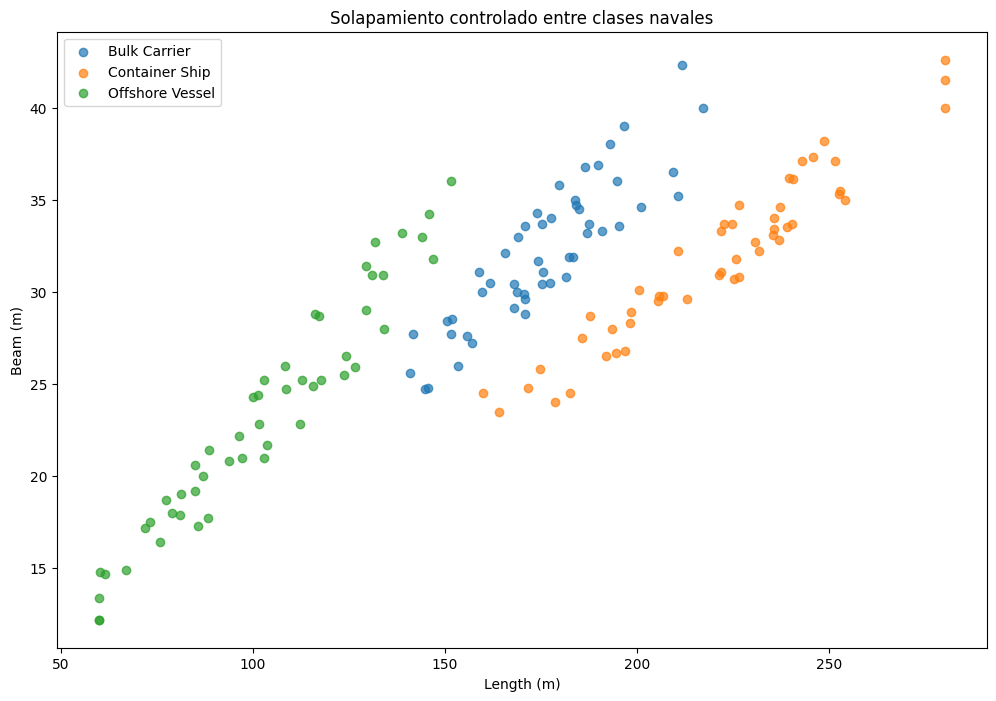

In [28]:
import numpy as np
import pandas as pd

np.random.seed(42)
num_samples = 150
filename = 'Naval_Dataset3.csv'

vessel_types = ['Bulk Carrier', 'Container Ship', 'Offshore Vessel']
data = []

# Bulk Carrier (50 samples) - Solapa con Container Ship en tamaño grande
length = np.clip(np.random.normal(180, 20, 50), 140, 220)
beam = length / np.random.uniform(5.0, 6.0, 50)  # Más anchos
draft = np.clip(np.random.normal(11, 1.5, 50), 8, 14)
displacement = np.clip(300 + 200*length + np.random.normal(0, 5000, 50), 25000, 60000)
data.extend(zip(length.round(1), beam.round(1), draft.round(1), displacement.round(0),
            [vessel_types[0]]*50))

# Container Ship (50 samples) - Solapa con ambos extremos
length = np.clip(np.random.normal(220, 30, 50), 160, 280)  # Más largos
beam = length / np.random.uniform(6.5, 7.5, 50)  # Más estrechos
draft = np.clip(np.random.normal(13, 2, 50), 9, 16)
displacement = np.clip(400 + 180*length + np.random.normal(0, 8000, 50), 30000, 70000)
data.extend(zip(length.round(1), beam.round(1), draft.round(1), displacement.round(0),
            [vessel_types[1]]*50))

# Offshore Vessel (50 samples) - Solapa con Bulk Carrier en tamaño mediano
length = np.clip(np.random.normal(100, 25, 50), 60, 160)
beam = length / np.random.uniform(4.0, 5.0, 50)  # Formas más robustas
draft = np.clip(np.random.normal(6, 1.8, 50), 4, 9)
displacement = np.clip(200 + 150*length + np.random.normal(0, 3000, 50), 10000, 30000)
data.extend(zip(length.round(1), beam.round(1), draft.round(1), displacement.round(0),
            [vessel_types[2]]*50))

df = pd.DataFrame(data)
df.to_csv(filename, header=False, index=False)

# Visualización del solapamiento
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
for i, vessel in enumerate(vessel_types):
    subset = df[df[4] == vessel]
    plt.scatter(subset[0], subset[1], label=vessel, alpha=0.7)
plt.xlabel('Length (m)')
plt.ylabel('Beam (m)')
plt.title('Solapamiento controlado entre clases navales')
plt.legend()
plt.show()

Optimized Global Statistics:
            0       1       2         3
count  150.00  150.00  150.00    150.00
mean   166.19   29.06   10.08  30565.24
std     54.73    6.45    3.47  12665.51
min     60.00   12.20    4.00  10000.00
25%    124.85   25.20    7.02  18670.25
50%    172.80   30.05   10.65  32725.00
75%    205.70   33.68   12.70  39452.75
max    280.00   42.60   16.00  62203.00


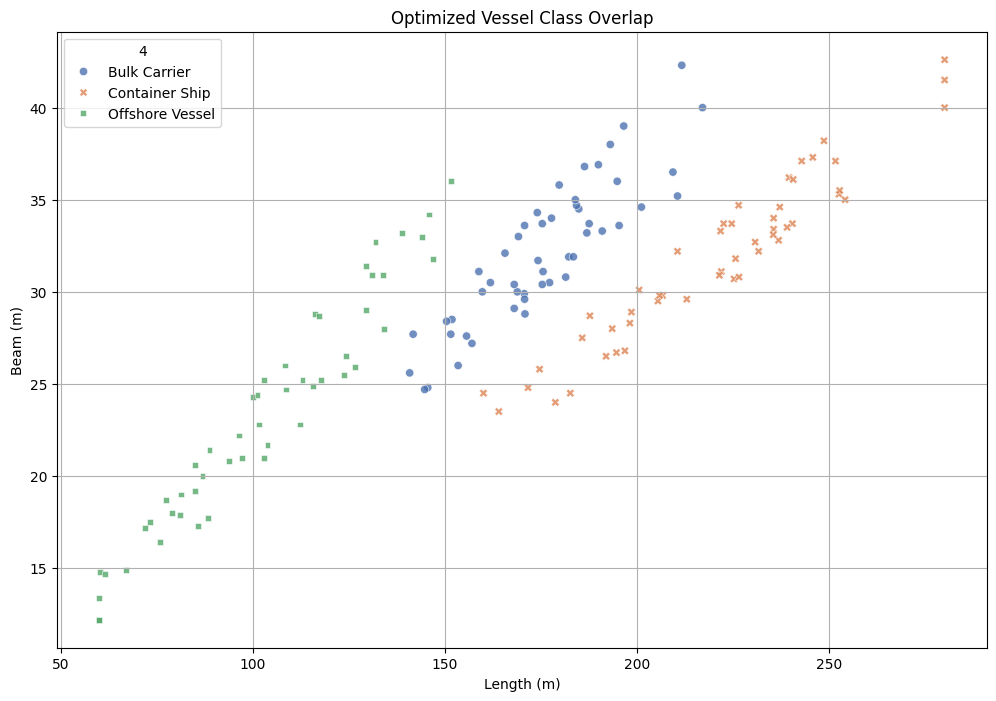

In [38]:
import numpy as np
import pandas as pd

np.random.seed(42)
num_samples = 150
filename = 'Naval_Dataset_Optimized.csv'

vessel_types = ['Bulk Carrier', 'Container Ship', 'Offshore Vessel']
data = []

# Parámetros optimizados para solapamiento controlado
params = {
    'Bulk Carrier': {
        'length': (180, 20, 140, 220),
        'beam_ratio': (5.0, 6.0),
        'draft': (11, 1.5, 8, 14),
        'disp_factor': (200, 5000, 25000, 60000)
    },
    'Container Ship': {
        'length': (220, 30, 160, 280),
        'beam_ratio': (6.5, 7.5),
        'draft': (13, 2, 9, 16),
        'disp_factor': (180, 8000, 30000, 70000)
    },
    'Offshore Vessel': {
        'length': (100, 25, 60, 160),
        'beam_ratio': (4.0, 5.0),
        'draft': (6, 1.8, 4, 9),
        'disp_factor': (150, 3000, 10000, 30000)
    }
}

for vessel in vessel_types:
    p = params[vessel]
    length = np.clip(np.random.normal(p['length'][0], p['length'][1], 50), p['length'][2], p['length'][3])
    beam = length / np.random.uniform(p['beam_ratio'][0], p['beam_ratio'][1], 50)
    draft = np.clip(np.random.normal(p['draft'][0], p['draft'][1], 50), p['draft'][2], p['draft'][3])
    displacement = np.clip(
        p['disp_factor'][0] * length + np.random.normal(0, p['disp_factor'][1], 50),
        p['disp_factor'][2], p['disp_factor'][3]
    )
    data.extend(zip(
        length.round(1),
        beam.round(1),
        draft.round(1),
        displacement.round(0),
        [vessel]*50
    ))

df = pd.DataFrame(data)
df.to_csv(filename, header=False, index=False)

# Estadísticas globales mejoradas
print("Optimized Global Statistics:")
print(df.iloc[:, :4].describe().round(2))

# Visualización de solapamiento
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x=0, y=1, hue=4, style=4, palette="deep", alpha=0.8)
plt.xlabel('Length (m)')
plt.ylabel('Beam (m)')
plt.title('Optimized Vessel Class Overlap')
plt.grid(True)
plt.show()